### Run DLC for perfect donut scans


### Step 1. Import packages

In [ ]:
import numpy as np
import matplotlib.pylab as plt
from pathlib import Path
import sys
import astropy.units as u

plt.ion()
#%matplotlib widget

file_path = '/Users/ashleybaker/Documents/DLC/'
# optional yaml file could feed
config_path = "../dlc_package/configs/gen_config.yaml"

sys.path.insert(0, str(Path(file_path) / "dlc_package"))
from obsdata_utils import cObsLog
from dlc import DifferentialLimbCoupling as dlc_class


### Now initiate the class with our settings

In [2]:
dlcc = dlc_class(diagnostics_on=False, 
                config=dict(xoffsets = [1], # just run a subset of the offsets for now
                            yoffsets = [0],
                            tt_dyn = [0],
                            theta=0 * u.deg, 
                            vsini=1*u.km/u.s, 
                            R=90000, 
                            bandpass='yJ',
                            diameter=1.0 * u.mas,
                            coupling_map_boundary=60*u.mas,
                            telescope='Keck'))




Loading /Users/ashleybaker/Documents/DLC/dlc_package/data/coupling_maps/staticModel_Keck_yJ_defoc0nmRMS_LO0nmRMS_Fnum3.67_atm0_adc0_nWvls10_PL0.fits
vel slope 0.0475853355 km / s
res vel 3331.0 m / s spec kernel wid 280004.5 m pix / km


### Now step through perfect scans
setting perfect_scan=True in run_jitter will make perfect circles. These can be plotted later to see

In [17]:
# step through r_in
d_ins = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
sims_vels_jitter = np.zeros(len(d_ins))
coupling_effs = np.zeros(len(d_ins))

# run on axis case to get 0
dlcc.run()
sims_vels_jitter[0] = 1000*dlcc.vels[0].value # just save last velocity which is 1 mas off, this is 0 case
coupling_effs[0] = dlcc.coupling_efficiency[0]

# now step through the different scanning ring radii
for i, d_in in enumerate(d_ins[1:], start=1):
    dlcc.run_ttjitter(r_in=d_in/2 * u.mas, perfect_scan=True)
    sims_vels_jitter[i] = 1000*dlcc.vels[0].value # just save last velocity which is 1 mas off
    coupling_effs[i] = dlcc.coupling_efficiency[0]


Running x,y position 1.0 mas 0.0 mas
vel -0.0005429780533167672 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0005368680195651966 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.000519331058270329 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00048588317256924844 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0004366213115592687 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0003665447465434554 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.000269721369297609 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00013386426457684302 km / s
Running x,y position 1.0 mas 0.0 mas
vel 6.008647297293509e-05 km / s
Running x,y position 1.0 mas 0.0 mas
vel 0.0003520776422210361 km / s
Running x,y position 1.0 mas 0.0 mas
vel 0.0008279800267494072 km / s
Running x,y position 1.0 mas 0.0 mas
vel 0.0017064039396180162 km / s


### Ok, now plot the result

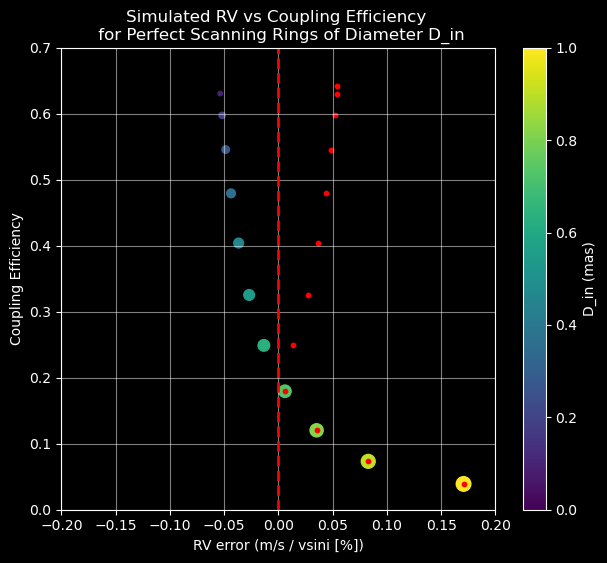

In [37]:
# PLOT
xaxis = 100*sims_vels_jitter/dlcc.vsini.to(u.m/u.s).value

plt.figure(figsize=(7,6))
plt.scatter(xaxis, coupling_effs,  c=d_ins, s=d_ins*2, cmap='viridis')
plt.scatter(np.abs(xaxis), coupling_effs,  c='r', s=10)
plt.colorbar(label='D_in (mas)')
plt.xlabel('RV error (m/s / vsini [%])')
plt.ylabel('Coupling Efficiency')
plt.title('Simulated RV vs Coupling Efficiency \n for Perfect Scanning Rings of Diameter D_in')
plt.grid(alpha=0.5)
plt.ylim(0, 0.7)
plt.xlim(-0.2, 0.2)
plt.axvline(0, c='r', ls='--',lw=2)
plt.savefig('RV_err_scan_circles.png', dpi=300)  # distinct from RVerr_scan_radius.py's RV_err_scan_radius.png


### Let's see what a scan looks like

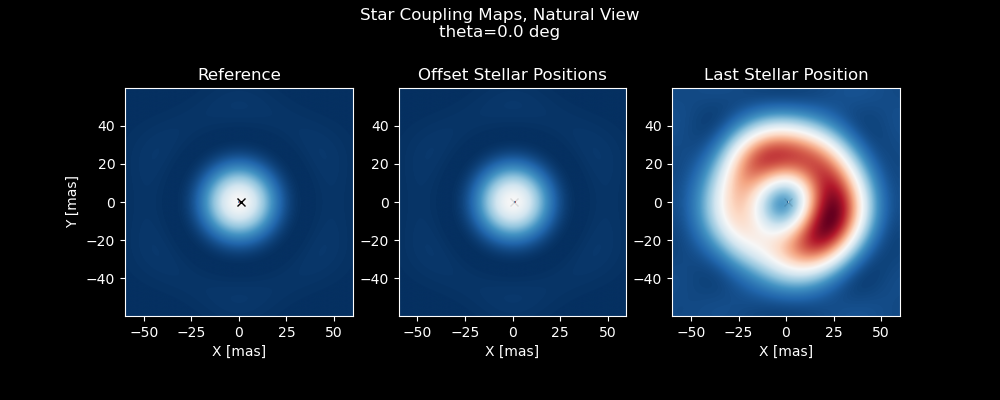

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

...

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

In [44]:
dlcc.plot_star_fiber()


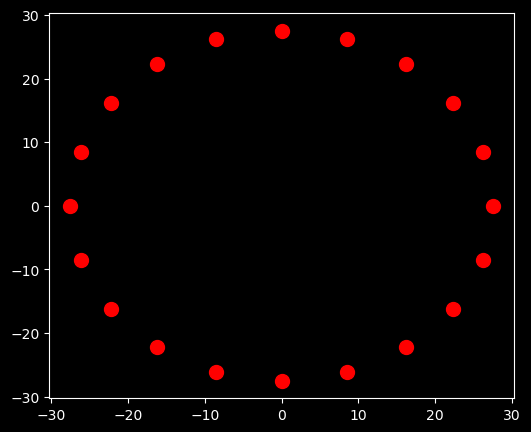

In [8]:
plt.figure(figsize=(6,5))
plt.scatter(dlcc.x_jitter[0], dlcc.y_jitter[0], c='red', s=100, label='TT Jitter Pattern')

# Now run a not perfect scan
    


In [25]:
# run on axis case to get 0
sims_vels_imperf = np.zeros(len(d_ins))
coupling_imperf = np.zeros(len(d_ins))

dlcc.run()
sims_vels_imperf[0] = 1000*dlcc.vels[0].value # just save last velocity which is 1 mas off, this is 0 case
coupling_imperf[0] = dlcc.coupling_efficiency[0]

# now step through the different scanning ring radii
for i, d_in in enumerate(d_ins[1:], start=1):
    print(f'Running {d_in} mas diameter scan')
    dlcc.run_ttjitter(exp_time=180*u.s, r_in=d_in/2 * u.mas, r_out=d_in/2 * u.mas, perfect_scan=False)
    sims_vels_imperf[i] = 1000*dlcc.vels[0].value # just save last velocity which is 1 mas off
    coupling_imperf[i] = dlcc.coupling_efficiency[0]



Running x,y position 1.0 mas 0.0 mas
vel -0.0005429780533167672 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0005014904905494134 km / s
Running x,y position 1.0 mas 0.0 mas


/Users/ashleybaker/Documents/DLC/dlc_package/dlc.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  # fit ccf vs v to find minimum


vel -3.208275844890655e-05 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0008114493144488063 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00046375697102052805 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00046304528826893296 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0012955898471618634 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0010056051025955418 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00026589773459511853 km / s
Running x,y position 1.0 mas 0.0 mas
vel 0.0007245899325820028 km / s
Running x,y position 1.0 mas 0.0 mas
vel 0.00014513355493794651 km / s
Running x,y position 1.0 mas 0.0 mas
vel 0.00521250934777114 km / s


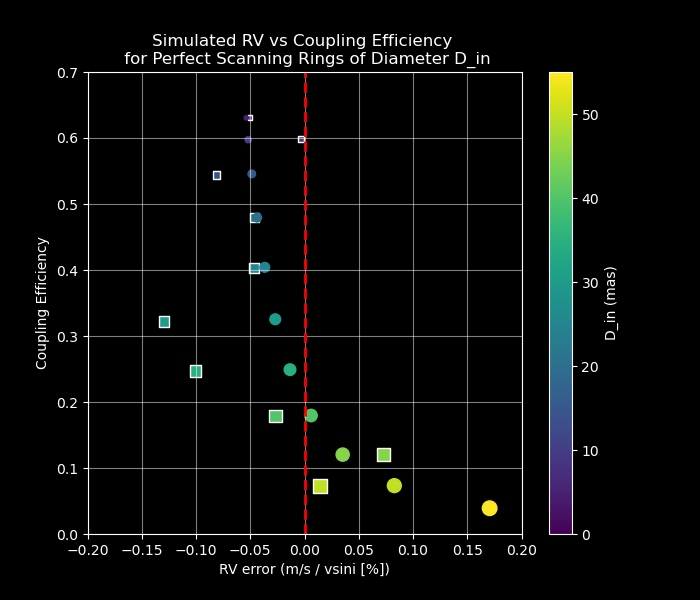

In [40]:
# PLOT
xaxis_imperf = 100*sims_vels_imperf/dlcc.vsini.to(u.m/u.s).value
xaxis = 100*sims_vels_jitter/dlcc.vsini.to(u.m/u.s).value

plt.figure(figsize=(7,6))
plt.scatter(xaxis_imperf, coupling_imperf,  c=d_ins, s=d_ins*2, marker='s', ec='white', cmap='viridis')
plt.scatter(xaxis, coupling_effs,  c=d_ins, s=d_ins*2, cmap='viridis')
plt.colorbar(label='D_in (mas)')
plt.xlabel('RV error (m/s / vsini [%])')
plt.ylabel('Coupling Efficiency')
plt.title('Simulated RV vs Coupling Efficiency \n for Perfect Scanning Rings of Diameter D_in')
plt.grid(alpha=0.5)
plt.ylim(0, 0.7)
plt.xlim(-0.2, 0.2)
plt.axvline(0, c='r', ls='--',lw=2)
plt.savefig('RV_err_scan_circles_imperfect.png', dpi=300)  # distinct from RVerr_scan_radius.py's RV_err_scan_radius.png
plt.show()

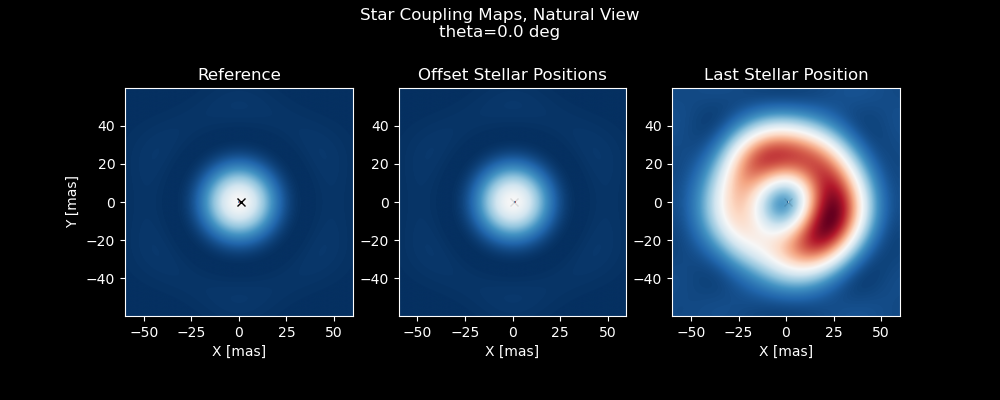

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

...

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

In [41]:
dlcc.plot_star_fiber()

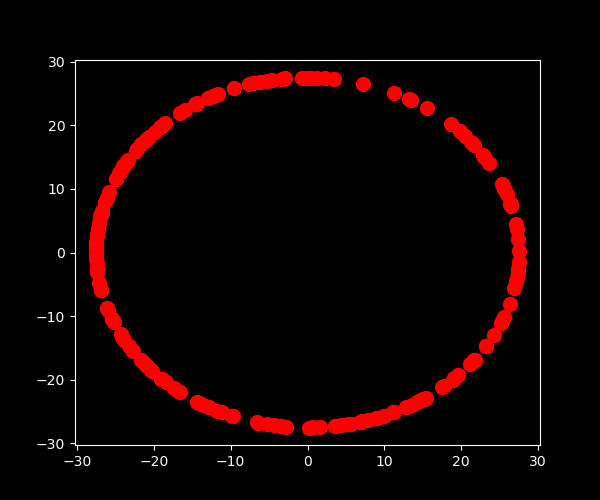

In [43]:
plt.figure(figsize=(6,5))
plt.scatter(dlcc.x_jitter[0], dlcc.y_jitter[0], c='red', s=100, label='TT Jitter Pattern')
